# Water Potability Prediction Project
This project aims to build machine learning models to predict whether water is drinkable or not based on its chemical properties.
The dataset contains multiple features such as pH, hardness, solids, and other chemical indicators.
This is a classification problem where:
- 0 = not drinkable water
- 1 = drinkable water

In [31]:
import pandas as pd

df = pd.read_csv('datawater_potability.csv')



## Data Exploratio
First, we explore the dataset to understand its structure, data types, and statistical properties.
We use:
- df.head() to view sample data
- df.info() to check missing values and data types
- df.describe() to analyze statistical distribution

In [32]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


The dataset contains missing values in several columns such as pH and Sulfate.
The features are numerical and vary in scale, which may affect model performance.
The target variable (Potability) is binary, indicating whether water is safe to drink.

## Data Preprocessing
To prepare the data for modeling:
- We separate features (X) and target variable (y)
- We handle missing values by replacing them with the mean of each column
This ensures that the dataset is clean and ready for machine learning models.

In [8]:
X = df.drop('Potability', axis=1)
y = df['Potability'] # we delete 'potability' column as data, cause it is our target

In [9]:
X = X.fillna(X.mean()) # we full the empty cells, we saw them when used info() command

We split the dataset into training and testing sets.
- 80% for training
- 20% for testing
This allows us to evaluate model performance on unseen data.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2620, 9)
(656, 9)
(2620,)
(656,)


## Logistic Regression Model
We first apply Logistic Regression as a baseline model.
This model assumes a linear relationship between features and the target.

In [ ]:
# Import model
from sklearn.linear_model import LogisticRegression
# Create model
model = LogisticRegression(max_iter=1000)  # increase iterations to avoid warning

In [13]:
# Train model on training data
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
# Make predictions on test data
y_pred = model.predict(X_test)

In [ ]:
# Import metric
from sklearn.metrics import accuracy_score
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6280487804878049


In [ ]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Print confusion matrix
print(cm)

[[412   0]
 [244   0]]


The Logistic Regression model shows relatively low performance.
It struggles to correctly classify drinkable water (class 1), which suggests that the relationship in the data is not purely linear.

In [17]:
# Import classification report
from sklearn.metrics import classification_report
# Print classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      1.00      0.77       412
           1       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [ ]:
# Import model
from sklearn.linear_model import LogisticRegression
# Create model with class_weight to handle imbalance
model = LogisticRegression(max_iter=1000, class_weight='balanced')
# Train model
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [19]:
# Predict again
y_pred = model.predict(X_test)

In [20]:
# Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

# Classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Accuracy: 0.5076219512195121
[[216 196]
 [127 117]]
              precision    recall  f1-score   support

           0       0.63      0.52      0.57       412
           1       0.37      0.48      0.42       244

    accuracy                           0.51       656
   macro avg       0.50      0.50      0.50       656
weighted avg       0.53      0.51      0.52       656



## Random Forest Model
Next, we use Random Forest, which is an ensemble learning method.
It builds multiple decision trees and combines their predictions, making it more powerful for complex datasets.

In [ ]:
# Import model
from sklearn.ensemble import RandomForestClassifier
# Create model
rf_model = RandomForestClassifier(random_state=42)
# Train model
rf_model.fit(X_train, y_train)
# Predict
y_pred_rf = rf_model.predict(X_test)

In [22]:
# Accuracy
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
# Confusion matrix
print(confusion_matrix(y_test, y_pred_rf))
# Classification report
print(classification_report(y_test, y_pred_rf))

RF Accuracy: 0.6783536585365854
[[353  59]
 [152  92]]
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       412
           1       0.61      0.38      0.47       244

    accuracy                           0.68       656
   macro avg       0.65      0.62      0.62       656
weighted avg       0.67      0.68      0.66       656



In [23]:
# Compare models
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.5076219512195121
Random Forest Accuracy: 0.6783536585365854


The Random Forest model significantly improves performance.
It captures non-linear patterns in the data better than Logistic Regression.
However, it still struggles with detecting class 1 (drinkable water).

## Hyperparameter Tuning
To improve model performance, we adjust key parameters of the Random Forest model:
- Increase number of trees
- Limit tree depth to reduce overfitting
This helps optimize the model.

In [24]:
# Import model
from sklearn.ensemble import RandomForestClassifier
# Create tuned Random Forest model
rf_tuned = RandomForestClassifier(
    n_estimators=200,   # number of trees
    max_depth=10,       # limit depth to reduce overfitting
    random_state=42
)
# Train tuned model
rf_tuned.fit(X_train, y_train)
# Make predictions
y_pred_tuned = rf_tuned.predict(X_test)

## Confusion Matrix Visualization
We visualize the confusion matrix using a heatmap to better understand model performance.
This helps identify how well the model predicts each class.

In [25]:
# Accuracy for tuned Random Forest
print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_tuned))
# Confusion matrix for tuned Random Forest
print(confusion_matrix(y_test, y_pred_tuned))
# Classification report for tuned Random Forest
print(classification_report(y_test, y_pred_tuned))

Tuned RF Accuracy: 0.6814024390243902
[[384  28]
 [181  63]]
              precision    recall  f1-score   support

           0       0.68      0.93      0.79       412
           1       0.69      0.26      0.38       244

    accuracy                           0.68       656
   macro avg       0.69      0.60      0.58       656
weighted avg       0.68      0.68      0.63       656



The tuned Random Forest model shows a slight improvement in accuracy.
However, the improvement is not very significant, indicating that the model may already be close to optimal performance.

In [26]:
# Final comparison of models
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_tuned))

Logistic Regression Accuracy: 0.5076219512195121
Random Forest Accuracy: 0.6783536585365854
Tuned Random Forest Accuracy: 0.6814024390243902


In [ ]:
# Final Model Selection
# Logistic Regression (balanced) improved detection of class 1 but reduced accuracy.
# Random Forest achieved the best balance between accuracy and class prediction.
# Tuned Random Forest did not significantly improve performance.
# Final choice: Random Forest is selected as the best-performing model.

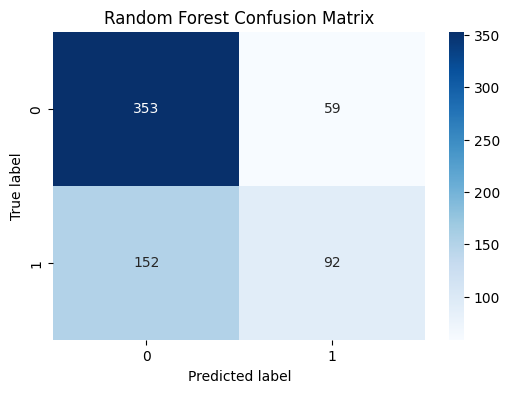

In [27]:
# Import libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns
# Create confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
# Add labels and title
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Random Forest Confusion Matrix")
# Show plot
plt.show()

## Model Prediction Example
We test the model on a single sample from the test dataset.
This demonstrates how the model works in practice.

In [30]:
# Take one sample from test data as DataFrame
sample = X_test.iloc[[0]]
# Show the sample features
print("Sample data:")
print(sample)
# Predict using tuned Random Forest
prediction = rf_tuned.predict(sample)
# Show predicted and actual class
print("Predicted class:", prediction[0])
print("Actual class:", y_test.iloc[0])

Sample data:
            ph    Hardness       Solids  Chloramines     Sulfate  \
2947  7.080795  183.521107  20461.25271     7.333212  333.119476   

      Conductivity  Organic_carbon  Trihalomethanes  Turbidity  
2947    356.369022       20.179029        67.019903   4.886634  
Predicted class: 0
Actual class: 0


## Final Conclusion
Three models were compared in this project:
- Logistic Regression
- Random Forest
- Tuned Random Forest
Results:
- Logistic Regression showed the weakest performance
- Random Forest achieved the best balance between accuracy and classification
- Hyperparameter tuning provided only a small improvement
Final Decision:
The Random Forest model is selected as the best-performing model.
Overall, the project demonstrates how different machine learning models can be applied and compared on a real dataset.